In [1]:
import numpy as np
import joblib
import pandas as pd
from skimage import measure
from skimage.measure import shannon_entropy
from skimage.transform import resize
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold

IMG_SIZE = (512, 256)  # до какого размера были сжаты изображения

In [73]:
X = joblib.load('X_cropped_diff_images_2_increase_ds.joblib')
X_coords = joblib.load('X_coords_diff_images_2_increase_ds.joblib')
y = joblib.load('y_labels_2_increase_ds.joblib')

print(f"Загружено {len(X)} изображений")
print(f"Загружено {len(X_coords)} координат левого верхнегно угла")
print(f"Загружено {len(y)} лейблов")

Загружено 818 изображений
Загружено 818 координат левого верхнегно угла
Загружено 818 лейблов


In [3]:
def extract_features(diff_image, top_left):
    """
    Извлекает признаки из diff-области.
    
    Parameters:
        diff_image: обрезанное diff-изображение
        top_left: кортеж (y, x) координат относительно исходного скриншота
    """
    features = {}
    
    h, w = diff_image.shape
    
    # 1. Геометрические признаки (bounding box)
    features['width'] = w
    features['height'] = h
    features['area_bbox'] = w * h
    features['aspect_ratio'] = w / h if h > 0 else 0
    features['relative_area'] = (w * h) / (IMG_SIZE[0] * IMG_SIZE[1])
    
    # 2. Позиционные признаки
    features['top_left_y'] = top_left[0]
    features['top_left_x'] = top_left[1]
    features['center_y_norm'] = (top_left[0] + h/2) / IMG_SIZE[1]
    features['center_x_norm'] = (top_left[1] + w/2) / IMG_SIZE[0]
    
    # 3. Признаки интенсивности
    features['mean_intensity'] = np.mean(diff_image)
    features['std_intensity'] = np.std(diff_image)
    features['max_intensity'] = np.max(diff_image)
    features['sum_intensity'] = np.sum(diff_image)
    features['nonzero_ratio'] = np.count_nonzero(diff_image) / diff_image.size
    
    # 4. Морфологические признаки (связные компоненты)
    binary = (diff_image > 0.01).astype(np.uint8)
    labeled = measure.label(binary, connectivity=2)
    regions = measure.regionprops(labeled)
    
    features['num_components'] = len(regions)
    
    if len(regions) > 0:
        areas = [r.area for r in regions]
        features['largest_component_area'] = max(areas)
        features['largest_component_ratio'] = max(areas) / (np.count_nonzero(binary) + 1)
        features['mean_component_area'] = np.mean(areas)
        features['std_component_area'] = np.std(areas) if len(areas) > 1 else 0
        
        # Характеристики крупнейшей компоненты
        largest_region = max(regions, key=lambda r: r.area)
        features['largest_compactness'] = (largest_region.perimeter ** 2) / (4 * np.pi * largest_region.area + 1)
        features['largest_eccentricity'] = largest_region.eccentricity
        features['largest_solidity'] = largest_region.solidity  # area / convex_area
        features['largest_extent'] = largest_region.extent  # area / bbox_area
        features['largest_orientation'] = largest_region.orientation
    else:
        features['largest_component_area'] = 0
        features['largest_component_ratio'] = 0
        features['mean_component_area'] = 0
        features['std_component_area'] = 0
        features['largest_compactness'] = 0
        features['largest_eccentricity'] = 0
        features['largest_solidity'] = 0
        features['largest_extent'] = 0
        features['largest_orientation'] = 0
    
    # 5. Текстурные признаки
    # Приводим к одному размеру для текстурного анализа
    resized = resize(diff_image, (32, 32), anti_aliasing=True)
    
    features['entropy'] = shannon_entropy(resized + 1e-10)
    
    # Статистики проекций
    row_proj = np.sum(resized, axis=1)
    col_proj = np.sum(resized, axis=0)
    features['std_row_projection'] = np.std(row_proj)
    features['std_col_projection'] = np.std(col_proj)
    features['max_row_projection'] = np.max(row_proj)
    features['max_col_projection'] = np.max(col_proj)
    
    return features


def create_feature_dataset(X_diff, X_coords):
    """
    Создает датафрейм с признаками для всех образцов.
    
    Parameters:
        X_diff: список обрезанных diff-изображений
        X_coords: список кортежей (y, x) верхнего левого угла
    """
    all_features = []
    
    for i, (diff_img, coords) in enumerate(zip(X_diff, X_coords)):
        features = extract_features(diff_img, coords)
        features['sample_id'] = i
        all_features.append(features)
    
    df = pd.DataFrame(all_features)
    return df

In [5]:
def compute_symmetry_score_enhanced(diff_images):
    """
    Делит diff-область пополам по вертикали и горизонтали,
    сравнивает половинки через среднюю абсолютную разницу.
    Возвращает минимальную разницу (0 = полная симметрия).
    Улучшенная версия с нормализацией и поиском симметрии с небольшим сдвигом
    """
    symmetry_score = []

    for diff_image in diff_images:
        h, w = diff_image.shape
        
        # Нормализация для устойчивости
        if diff_image.max() > 0:
            diff_norm = diff_image / diff_image.max()
        else:
            symmetry_score.append(0)
            continue
        
        best_score = float('inf')
        
        # Пробуем разные точки разделения для поиска наилучшей симметрии
        for offset in range(-2, 3):  # Небольшой сдвиг
            mid_w = (w // 2) + offset
            if mid_w <= 0 or mid_w >= w:
                continue
                
            left = diff_norm[:, :mid_w]
            right = np.fliplr(diff_norm[:, mid_w:2*mid_w]) if 2*mid_w <= w else np.fliplr(diff_norm[:, w-mid_w:])
            
            # Приводим к одному размеру
            min_w = min(left.shape[1], right.shape[1])
            if min_w > 0:
                vert_diff = np.mean(np.abs(left[:, :min_w] - right[:, :min_w]))
                best_score = min(best_score, vert_diff)
        
        symmetry_score.append(best_score)
    
    return symmetry_score

In [6]:
def detect_duplicated_pattern(diff_images):
    """
    Ищет повторяющиеся вертикальные паттерны в diff-изображении.
    Возвращает score (0 = идеальное повторение, т.е. явный сдвиг)
    """
    duplicate_pattern_best_score = []
    duplicate_pattern_best_shift = []
    for diff_image in diff_images:
        h, w = diff_image.shape
        
        if h < 10 or w < 10:
            return 1.0
        
        best_score = 1.0
        best_shift = 0
        
        # Ищем повторяющиеся колонки/блоки
        # Пробуем разные сдвиги (половина ширины и другие)
        for shift_ratio in [0.5, 0.33, 0.25]:  # Проверяем разные соотношения
            shift = int(w * shift_ratio)
            if shift < 10:
                continue
                
            # Сравниваем левую часть с правой (со сдвигом)
            for start in range(0, w - shift, max(1, shift // 4)):
                left_block = diff_image[:, start:start + shift]
                right_block = diff_image[:, start + shift:start + 2*shift]
                
                if right_block.shape[1] >= shift * 0.8:
                    # Обрезаем до одинакового размера
                    min_w = min(left_block.shape[1], right_block.shape[1])
                    if min_w > 5:
                        # Нормализуем
                        left_norm = left_block[:, :min_w].astype(float)
                        right_norm = right_block[:, :min_w].astype(float)
                        
                        if left_norm.max() > 0:
                            left_norm /= left_norm.max()
                        if right_norm.max() > 0:
                            right_norm /= right_norm.max()
                        
                        similarity = np.mean(np.abs(left_norm - right_norm))
                        
                        if similarity < best_score:
                            best_score = similarity
                            best_shift = shift
        
        duplicate_pattern_best_score.append(best_score)
        duplicate_pattern_best_shift.append(best_shift)
    return duplicate_pattern_best_score, duplicate_pattern_best_shift

In [74]:
df_features = create_feature_dataset(X, X_coords)
df_features['symmetry_score'] = compute_symmetry_score_enhanced(X)
duplicated_pattern = detect_duplicated_pattern(X)
df_features['duplicated_pattern_best_score'] = duplicated_pattern[0]
df_features['duplicated_pattern_best_shift'] = duplicated_pattern[1]

print(f"Размер датафрейма: {df_features.shape}")
print(f"Количество признаков: {df_features.shape[1] - 1}")
print("\nПервые 5 строк:")
print(df_features.head())
print("\nСтатистика по признакам:")
print(df_features.describe())

Размер датафрейма: (818, 33)
Количество признаков: 32

Первые 5 строк:
   width  height  area_bbox  aspect_ratio  relative_area  top_left_y  \
0    115      59       6785      1.949153       0.051765          33   
1    179      60      10740      2.983333       0.081940         162   
2    423      61      25803      6.934426       0.196861          99   
3     37      24        888      1.541667       0.006775         128   
4    115      58       6670      1.982759       0.050888          34   

   top_left_x  center_y_norm  center_x_norm  mean_intensity  ...  \
0         259       0.244141       0.618164        0.006381  ...   
1          53       0.750000       0.278320        0.075124  ...   
2          40       0.505859       0.491211        0.039315  ...   
3          46       0.546875       0.125977        0.032883  ...   
4         259       0.246094       0.618164        0.006447  ...   

   largest_orientation   entropy  std_row_projection  std_col_projection  \
0        -2

In [75]:
# Создаём метки подтипов на основе индексов
subtype_labels = []
for i in range(len(df_features)):
    if i < 200:
        subtype_labels.append('disappeared')
    elif i < 250:
        subtype_labels.append('color_change')
    elif i < 400:
        subtype_labels.append('shift')
    elif i < 500:
        subtype_labels.append('dynamic')
    else:
        subtype_labels.append('banner')

subtype_labels = np.array(subtype_labels)

In [76]:
X_features = df_features.drop(['sample_id'], axis=1)
original_indices = np.arange(len(X_features))

X_train, X_test, y_train, y_test, sub_train, sub_test, idx_train, idx_test = train_test_split(
    X_features, y, subtype_labels, original_indices,
    test_size=0.3,
    stratify=subtype_labels,
    random_state=69
)

rf = RandomForestClassifier(n_estimators=100, random_state=69)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred))

# Важность признаков
feature_importance = pd.DataFrame({
    'feature': X_features.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\nТоп-10 важных признаков:")
print(feature_importance.head(10))

              precision    recall  f1-score   support

           0       0.95      0.98      0.97       126
           1       0.98      0.95      0.97       120

    accuracy                           0.97       246
   macro avg       0.97      0.97      0.97       246
weighted avg       0.97      0.97      0.97       246


Топ-10 важных признаков:
                   feature  importance
4            relative_area    0.128900
1                   height    0.115450
2                area_bbox    0.090442
15  largest_component_area    0.081495
0                    width    0.064600
12           sum_intensity    0.060152
8            center_x_norm    0.033972
7            center_y_norm    0.032996
18      std_component_area    0.029407
11           max_intensity    0.027847


In [10]:
# Детальный отчёт по подтипам
for subtype in np.unique(sub_test):
    mask = (sub_test == subtype)
    print(f"\n=== {subtype} ===")
    print(classification_report(y_test[mask], y_pred[mask]))


=== banner ===
              precision    recall  f1-score   support

           0       1.00      0.99      0.99        96
           1       0.00      0.00      0.00         0

    accuracy                           0.99        96
   macro avg       0.50      0.49      0.50        96
weighted avg       1.00      0.99      0.99        96


=== color_change ===
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       1.00      0.93      0.97        15

    accuracy                           0.93        15
   macro avg       0.50      0.47      0.48        15
weighted avg       1.00      0.93      0.97        15


=== disappeared ===
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       1.00      0.97      0.98        60

    accuracy                           0.97        60
   macro avg       0.50      0.48      0.49        60
weighted avg   

/home/slava/edu_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/slava/edu_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/slava/edu_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/slava/edu_env/lib/python3.12

Индексы с ошибками [387 143 313 465 226 142 690 280]


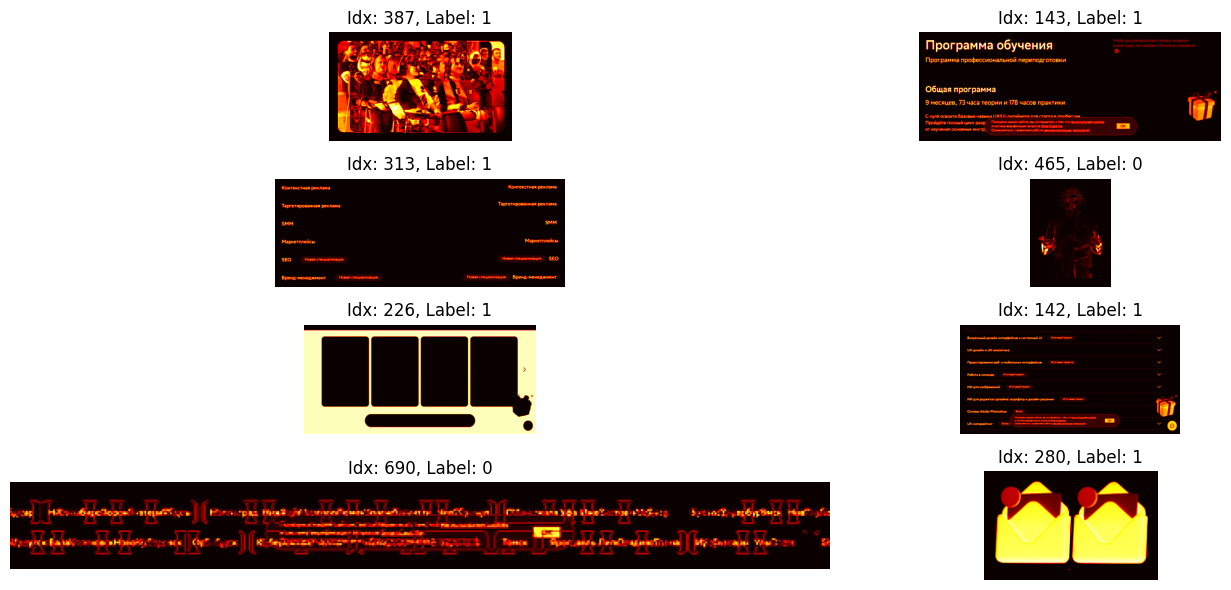

In [11]:
error_indexes = np.where(y_pred != y_test)[0]
incorrect_original_indices = idx_test[error_indexes]
print(f"Индексы с ошибками {incorrect_original_indices}")


fig, axes = plt.subplots(4, 2, figsize=(15, 6))
for i, ax in enumerate(axes.flat):
    if i < len(incorrect_original_indices):
        idx = incorrect_original_indices[i]
        if idx < len(X):
            ax.imshow(X[idx], cmap='hot')
            ax.set_title(f'Idx: {idx}, Label: {y[idx]}')
            ax.axis('off')
plt.tight_layout()
plt.show()

In [62]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Стандартизация признаков (важно для логистической регрессии)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Обучение модели логистической регрессии
lr = LogisticRegression(random_state=69, max_iter=1000)
lr.fit(X_train_scaled, y_train)

y_pred = lr.predict(X_test_scaled)
print(classification_report(y_test, y_pred))

feature_importance = pd.DataFrame({
    'feature': X_features.columns,
    'importance': np.mean(np.abs(lr.coef_), axis=0)  # Среднее абсолютных значений коэффициентов
}).sort_values('importance', ascending=False)

print("\nТоп-10 важных признаков:")
print(feature_importance.head(10))

              precision    recall  f1-score   support

           0       0.91      0.94      0.93       126
           1       0.94      0.90      0.92       120

    accuracy                           0.92       246
   macro avg       0.92      0.92      0.92       246
weighted avg       0.92      0.92      0.92       246


Топ-10 важных признаков:
                   feature  importance
10           std_intensity    3.555002
9           mean_intensity    2.619117
11           max_intensity    1.842045
0                    width    1.582413
15  largest_component_area    1.495257
3             aspect_ratio    1.142593
8            center_x_norm    1.072278
27      max_row_projection    0.964602
22          largest_extent    0.957192
7            center_y_norm    0.903561


In [14]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=69,
    use_label_encoder=False,
    eval_metric='logloss'
)
xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)
print(classification_report(y_test, y_pred))

# Важность признаков
importance = pd.DataFrame({
    'feature': X_features.columns,
    'importance': xgb.feature_importances_
}).sort_values('importance', ascending=False)
print(importance.head(10))

/home/slava/edu_env/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [09:02:26] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

           0       0.95      0.99      0.97       126
           1       0.99      0.95      0.97       120

    accuracy                           0.97       246
   macro avg       0.97      0.97      0.97       246
weighted avg       0.97      0.97      0.97       246

               feature  importance
2            area_bbox    0.333486
7        center_y_norm    0.087064
13       nonzero_ratio    0.079727
28  max_col_projection    0.067099
10       std_intensity    0.055982
12       sum_intensity    0.041896
6           top_left_x    0.036611
9       mean_intensity    0.031719
1               height    0.028823
0                width    0.028629


In [16]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=69,
    verbose=-1
)
lgbm.fit(X_train, y_train)
y_pred = lgbm.predict(X_test)
print(classification_report(y_test, y_pred))

# Важность признаков
importance = pd.DataFrame({
    'feature': X_features.columns,
    'importance': lgbm.feature_importances_
}).sort_values('importance', ascending=False)
print(importance.head(10))

              precision    recall  f1-score   support

           0       0.97      0.98      0.98       126
           1       0.98      0.97      0.97       120

    accuracy                           0.98       246
   macro avg       0.98      0.98      0.98       246
weighted avg       0.98      0.98      0.98       246

                          feature  importance
12                  sum_intensity         160
2                       area_bbox         134
19            largest_compactness         118
7                   center_y_norm          99
0                           width          98
11                  max_intensity          72
16        largest_component_ratio          68
6                      top_left_x          68
13                  nonzero_ratio          67
31  duplicated_pattern_best_shift          64


In [23]:
from catboost import CatBoostClassifier

catb = CatBoostClassifier(
    iterations=100,
    learning_rate=0.1,
    depth=6,
    random_seed=69,
    verbose=False
)
catb.fit(X_train, y_train)
y_pred = catb.predict(X_test)
print(classification_report(y_test, y_pred))

# Важность признаков
importance = pd.DataFrame({
    'feature': X_features.columns,
    'importance': catb.feature_importances_
}).sort_values('importance', ascending=False)
print(importance.head(10))

              precision    recall  f1-score   support

           0       0.97      0.98      0.98       126
           1       0.98      0.97      0.97       120

    accuracy                           0.98       246
   macro avg       0.98      0.98      0.98       246
weighted avg       0.98      0.98      0.98       246

                   feature  importance
6               top_left_x   15.545699
4            relative_area    8.678805
15  largest_component_area    8.678671
12           sum_intensity    7.724861
2                area_bbox    5.423158
8            center_x_norm    4.715883
11           max_intensity    4.603633
0                    width    4.519773
22          largest_extent    3.621799
24                 entropy    3.554777


In [63]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=69)
svm.fit(X_train_scaled, y_train)
y_pred = svm.predict(X_test_scaled)
print(classification_report(y_test, y_pred))

# Важность признаков (для линейного ядра)
svm_linear = SVC(kernel='linear', C=1.0, random_state=69)
svm_linear.fit(X_train_scaled, y_train)
importance = pd.DataFrame({
    'feature': X_features.columns,
    'importance': np.abs(svm_linear.coef_[0])
}).sort_values('importance', ascending=False)
print(importance.head(10))

              precision    recall  f1-score   support

           0       0.95      0.99      0.97       126
           1       0.99      0.94      0.97       120

    accuracy                           0.97       246
   macro avg       0.97      0.97      0.97       246
weighted avg       0.97      0.97      0.97       246

                   feature  importance
10           std_intensity    3.244584
9           mean_intensity    2.458261
15  largest_component_area    1.463027
11           max_intensity    1.315911
0                    width    1.059328
12           sum_intensity    0.887310
22          largest_extent    0.801659
27      max_row_projection    0.734686
21        largest_solidity    0.688771
3             aspect_ratio    0.614809


In [64]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred = knn.predict(X_test_scaled)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      1.00      0.96       126
           1       1.00      0.92      0.96       120

    accuracy                           0.96       246
   macro avg       0.96      0.96      0.96       246
weighted avg       0.96      0.96      0.96       246



In [22]:
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred = gnb.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.74      0.23      0.35       126
           1       0.53      0.92      0.67       120

    accuracy                           0.57       246
   macro avg       0.64      0.57      0.51       246
weighted avg       0.64      0.57      0.51       246



In [60]:
from sklearn.ensemble import VotingClassifier

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

voting = VotingClassifier(
    estimators=[
        # ('catb', CatBoostClassifier(iterations=100, learning_rate=0.1, depth=6, random_seed=69, verbose=False)),
        # ('rf', RandomForestClassifier(n_estimators=100, random_state=69)),
        ('xgb', XGBClassifier(n_estimators=100, random_state=69, use_label_encoder=False, eval_metric='logloss')),
        ('lgbm', LGBMClassifier(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=69,verbose=-1))
    ],
    voting='soft' 
)
voting.fit(X_train_scaled, y_train)
y_pred = voting.predict(X_test_scaled)
print(classification_report(y_test, y_pred))

/home/slava/edu_env/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [10:01:10] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

           0       0.98      0.99      0.98       126
           1       0.99      0.97      0.98       120

    accuracy                           0.98       246
   macro avg       0.98      0.98      0.98       246
weighted avg       0.98      0.98      0.98       246



### Выводы

Сравнивали с RandomForest:
```
              precision    recall  f1-score   support

           0       0.95      0.98      0.97       126
           1       0.98      0.95      0.97       120

    accuracy                           0.97       246
   macro avg       0.97      0.97      0.97       246
weighted avg       0.97      0.97      0.97       246
```

LogisticRegression дала 0,92, что показывает, что признаки рабочие и даже простая модель справляется.
GaussianNB показал плохой результат, так как данные сильно зависимые: лощадь и ширина и высота.

CatBoostClassifier, XGBClassifier и LGBMClassifier показали чуть лучший результат чем RandomForest, а ансабль ещё чуток лучше. Но главный вывод, что признаки дают отличный предсказуемый результат.

In [41]:
X = joblib.load('X_cropped_diff_images_5_other_domain.joblib')
X_coords = joblib.load('X_coords_diff_images_5_other_domain.joblib')
y = joblib.load('y_labels_5_other_domain.joblib')

print(f"Загружено {len(X)} изображений")
print(f"Загружено {len(X_coords)} координат левого верхнегно угла")
print(f"Загружено {len(y)} лейблов")

Загружено 110 изображений
Загружено 110 координат левого верхнегно угла
Загружено 110 лейблов


In [42]:
df_features = create_feature_dataset(X, X_coords)
df_features['symmetry_score'] = compute_symmetry_score_enhanced(X)
duplicated_pattern = detect_duplicated_pattern(X)
df_features['duplicated_pattern_best_score'] = duplicated_pattern[0]
df_features['duplicated_pattern_best_shift'] = duplicated_pattern[1]
print(df_features.describe())

            width      height      area_bbox  aspect_ratio  relative_area  \
count  110.000000  110.000000     110.000000    110.000000     110.000000   
mean   227.781818   77.827273   20709.763636      4.088142       0.158003   
std    160.449391   63.416182   25635.677754      3.733191       0.195585   
min     10.000000   10.000000     100.000000      0.123348       0.000763   
25%     91.750000   34.250000    3896.000000      1.484681       0.029724   
50%    216.000000   47.500000   10152.000000      2.378690       0.077454   
75%    364.000000  114.000000   30720.000000      6.363304       0.234375   
max    512.000000  246.000000  125952.000000     18.285714       0.960938   

       top_left_y  top_left_x  center_y_norm  center_x_norm  mean_intensity  \
count  110.000000  110.000000     110.000000     110.000000      110.000000   
mean   100.554545  133.063636       0.544798       0.482333        0.079762   
std     80.228068  136.441154       0.286477       0.235542        0.

In [43]:
# Создаём метки подтипов на основе индексов
subtype_labels = []
for i in range(len(df_features)):
    if i < 20:
        subtype_labels.append('disappeared')
    elif i < 40:
        subtype_labels.append('color_change')
    elif i < 70:
        subtype_labels.append('shift')
    elif i < 88:
        subtype_labels.append('dynamic')
    else:
        subtype_labels.append('banner')

subtype_labels = np.array(subtype_labels)

X_features = df_features.drop(['sample_id'], axis=1)
original_indices = np.arange(len(X_features))

In [44]:
y_pred = rf.predict(X_features)
print(classification_report(y, y_pred))

# Важность признаков
feature_importance = pd.DataFrame({
    'feature': X_features.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\nТоп-10 важных признаков:")
print(feature_importance.head(10))

              precision    recall  f1-score   support

           0       0.90      0.70      0.79        40
           1       0.85      0.96      0.90        70

    accuracy                           0.86       110
   macro avg       0.88      0.83      0.84       110
weighted avg       0.87      0.86      0.86       110


Топ-10 важных признаков:
                   feature  importance
4            relative_area    0.128900
1                   height    0.115450
2                area_bbox    0.090442
15  largest_component_area    0.081495
0                    width    0.064600
12           sum_intensity    0.060152
8            center_x_norm    0.033972
7            center_y_norm    0.032996
18      std_component_area    0.029407
11           max_intensity    0.027847


In [47]:
y_pred = xgb.predict(X_features)
print(classification_report(y, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.65      0.74        40
           1       0.82      0.94      0.88        70

    accuracy                           0.84       110
   macro avg       0.85      0.80      0.81       110
weighted avg       0.84      0.84      0.83       110



In [48]:
y_pred = lgbm.predict(X_features)
print(classification_report(y, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.60      0.71        40
           1       0.80      0.94      0.87        70

    accuracy                           0.82       110
   macro avg       0.83      0.77      0.79       110
weighted avg       0.82      0.82      0.81       110



In [68]:
y_pred = catb.predict(X_features)
print(classification_report(y, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.88      0.90        40
           1       0.93      0.96      0.94        70

    accuracy                           0.93       110
   macro avg       0.93      0.92      0.92       110
weighted avg       0.93      0.93      0.93       110



In [66]:
X_test_scaled = scaler.transform(X_features)
y_pred = svm.predict(X_test_scaled)
print(classification_report(y, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.90      0.91        40
           1       0.94      0.96      0.95        70

    accuracy                           0.94       110
   macro avg       0.93      0.93      0.93       110
weighted avg       0.94      0.94      0.94       110



In [67]:
y_pred = lr.predict(X_test_scaled)
print(classification_report(y, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.80      0.84        40
           1       0.89      0.94      0.92        70

    accuracy                           0.89       110
   macro avg       0.89      0.87      0.88       110
weighted avg       0.89      0.89      0.89       110



              precision    recall  f1-score   support

           0       0.97      0.98      0.98       126
           1       0.98      0.97      0.97       120

    accuracy                           0.98       246
   macro avg       0.98      0.98      0.98       246
weighted avg       0.98      0.98      0.98       246


Топ-10 важных признаков:
                   feature  importance
4            relative_area    0.128900
1                   height    0.115450
2                area_bbox    0.090442
15  largest_component_area    0.081495
0                    width    0.064600
12           sum_intensity    0.060152
8            center_x_norm    0.033972
7            center_y_norm    0.032996
18      std_component_area    0.029407
11           max_intensity    0.027847
Индексы с ошибками [358 357 387 465 491 226]


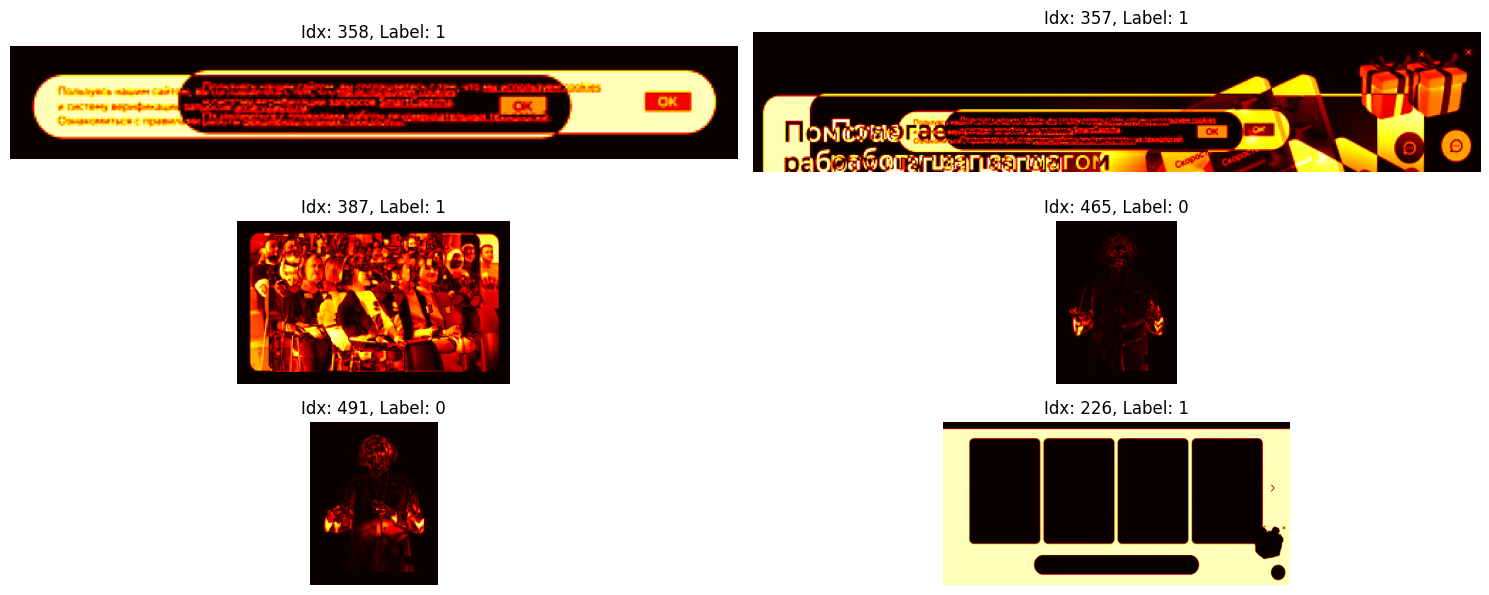

In [78]:
y_pred = catb.predict(X_test)
print(classification_report(y_test, y_pred))

# Важность признаков
feature_importance = pd.DataFrame({
    'feature': X_features.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\nТоп-10 важных признаков:")
print(feature_importance.head(10))

error_indexes = np.where(y_pred != y_test)[0]
incorrect_original_indices = idx_test[error_indexes]
print(f"Индексы с ошибками {incorrect_original_indices}")


fig, axes = plt.subplots(3, 2, figsize=(15, 6))
for i, ax in enumerate(axes.flat):
    if i < len(incorrect_original_indices):
        idx = incorrect_original_indices[i]
        if idx < len(X):
            ax.imshow(X[idx], cmap='hot')
            ax.set_title(f'Idx: {idx}, Label: {y[idx]}')
            ax.axis('off')
plt.tight_layout()
plt.show()

In [79]:
# Детальный отчёт по подтипам
for subtype in np.unique(sub_test):
    mask = (sub_test == subtype)
    print(f"\n=== {subtype} ===")
    print(classification_report(y_test[mask], y_pred[mask]))


=== banner ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        96

    accuracy                           1.00        96
   macro avg       1.00      1.00      1.00        96
weighted avg       1.00      1.00      1.00        96


=== color_change ===
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       1.00      0.93      0.97        15

    accuracy                           0.93        15
   macro avg       0.50      0.47      0.48        15
weighted avg       1.00      0.93      0.97        15


=== disappeared ===
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        60

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60


=== dynamic ===
              precision    recall  f1-score   suppo

/home/slava/edu_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/slava/edu_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/slava/edu_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/slava/edu_env/lib/python3.12

In [80]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=69)

subtype_metrics = {st: {'accuracy': []} for st in np.unique(subtype_labels)}

fold_accuracies = []
all_y_true = []
all_y_pred = []

print("=" * 50)
print("РЕЗУЛЬТАТЫ КРОСС-ВАЛИДАЦИИ")
print("=" * 50)

for fold, (train_idx, test_idx) in enumerate(skf.split(X_features, subtype_labels)):
    X_tr, X_te = X_features.iloc[train_idx], X_features.iloc[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]
    sub_te = subtype_labels[test_idx]
    
    model = CatBoostClassifier(iterations=100, learning_rate=0.1, depth=6, random_seed=69, verbose=False)
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    
    all_y_true.extend(y_te)
    all_y_pred.extend(y_pred)
    
    fold_acc = accuracy_score(y_te, y_pred)
    fold_accuracies.append(fold_acc)
    
    print(f"\nФолд {fold+1}: accuracy = {fold_acc:.4f}")
    
    for subtype in np.unique(sub_te):
        mask = (sub_te == subtype)
        if mask.sum() > 0:
            st_acc = accuracy_score(y_te[mask], y_pred[mask])
            subtype_metrics[subtype]['accuracy'].append(st_acc)

print("\n" + "=" * 50)
print("ИТОГОВЫЕ МЕТРИКИ")
print("=" * 50)

print(f"\nСредняя accuracy: {np.mean(fold_accuracies):.4f} ± {np.std(fold_accuracies):.4f}")
print(f"95% ДИ: {np.mean(fold_accuracies) - 1.96*np.std(fold_accuracies):.4f} - "
      f"{np.mean(fold_accuracies) + 1.96*np.std(fold_accuracies):.4f}")

print("\nAccuracy по подтипам:")
print("-" * 40)
for subtype in np.unique(subtype_labels):
    accs = subtype_metrics[subtype]['accuracy']
    print(f"{subtype:15s}: {np.mean(accs):.4f} ± {np.std(accs):.4f}  (по {len(accs)} фолдам)")

print("\nОбщий classification report:")
print("-" * 40)
print(classification_report(all_y_true, all_y_pred, target_names=['Not Bug', 'Bug']))

РЕЗУЛЬТАТЫ КРОСС-ВАЛИДАЦИИ

Фолд 1: accuracy = 0.9939

Фолд 2: accuracy = 0.9939

Фолд 3: accuracy = 0.9817

Фолд 4: accuracy = 0.9877

Фолд 5: accuracy = 0.9877

ИТОГОВЫЕ МЕТРИКИ

Средняя accuracy: 0.9890 ± 0.0046
95% ДИ: 0.9800 - 0.9980

Accuracy по подтипам:
----------------------------------------
banner         : 0.9968 ± 0.0063  (по 5 фолдам)
color_change   : 1.0000 ± 0.0000  (по 5 фолдам)
disappeared    : 0.9850 ± 0.0122  (по 5 фолдам)
dynamic        : 0.9800 ± 0.0400  (по 5 фолдам)
shift          : 0.9800 ± 0.0267  (по 5 фолдам)

Общий classification report:
----------------------------------------
              precision    recall  f1-score   support

     Not Bug       0.99      0.99      0.99       418
         Bug       0.99      0.98      0.99       400

    accuracy                           0.99       818
   macro avg       0.99      0.99      0.99       818
weighted avg       0.99      0.99      0.99       818



### Пермутационный тест

In [81]:
X = joblib.load('X_cropped_diff_images_2_increase_ds.joblib')
X_coords = joblib.load('X_coords_diff_images_2_increase_ds.joblib')
y = joblib.load('y_labels_2_increase_ds.joblib')

print(f"Загружено {len(X)} изображений")
print(f"Загружено {len(X_coords)} координат левого верхнегно угла")
print(f"Загружено {len(y)} лейблов")

Загружено 818 изображений
Загружено 818 координат левого верхнегно угла
Загружено 818 лейблов


In [82]:
# Создаём метки подтипов на основе индексов
subtype_labels = []
for i in range(len(df_features)):
    if i < 200:
        subtype_labels.append('disappeared')
    elif i < 250:
        subtype_labels.append('color_change')
    elif i < 400:
        subtype_labels.append('shift')
    elif i < 500:
        subtype_labels.append('dynamic')
    else:
        subtype_labels.append('banner')

subtype_labels = np.array(subtype_labels)

In [83]:
df_features = create_feature_dataset(X, X_coords)
df_features['symmetry_score'] = compute_symmetry_score_enhanced(X)
duplicated_pattern = detect_duplicated_pattern(X)
df_features['duplicated_pattern_best_score'] = duplicated_pattern[0]
df_features['duplicated_pattern_best_shift'] = duplicated_pattern[1]

print(f"Размер датафрейма: {df_features.shape}")
print(f"Количество признаков: {df_features.shape[1] - 1}")
print("\nПервые 5 строк:")
print(df_features.head())
print("\nСтатистика по признакам:")
print(df_features.describe())

Размер датафрейма: (818, 33)
Количество признаков: 32

Первые 5 строк:
   width  height  area_bbox  aspect_ratio  relative_area  top_left_y  \
0    115      59       6785      1.949153       0.051765          33   
1    179      60      10740      2.983333       0.081940         162   
2    423      61      25803      6.934426       0.196861          99   
3     37      24        888      1.541667       0.006775         128   
4    115      58       6670      1.982759       0.050888          34   

   top_left_x  center_y_norm  center_x_norm  mean_intensity  ...  \
0         259       0.244141       0.618164        0.006381  ...   
1          53       0.750000       0.278320        0.075124  ...   
2          40       0.505859       0.491211        0.039315  ...   
3          46       0.546875       0.125977        0.032883  ...   
4         259       0.246094       0.618164        0.006447  ...   

   largest_orientation   entropy  std_row_projection  std_col_projection  \
0        -2

In [88]:
X_features = df_features.drop(['sample_id'], axis=1)
original_indices = np.arange(len(X_features))

X_train, X_test, y_train, y_test, sub_train, sub_test, idx_train, idx_test = train_test_split(
    X_features, y, subtype_labels, original_indices,
    test_size=0.3,
    stratify=subtype_labels,
    random_state=69
)

catb_orig = CatBoostClassifier(iterations=100, learning_rate=0.1, depth=6, random_seed=69, verbose=False)
catb_orig.fit(X_train, y_train)
y_pred_orig = catb_orig.predict(X_test)
orig_acc = accuracy_score(y_test, y_pred_orig)
print(f"Оригинальная accuracy: {orig_acc:.4f}")

n_permutations = 20
permuted_accs = []

for i in range(n_permutations):
    y_train_shuffled = np.random.permutation(y_train)
    
    catb_perm = CatBoostClassifier(iterations=100, learning_rate=0.1, depth=6, random_seed=69, verbose=False)
    catb_perm.fit(X_train, y_train_shuffled)
    y_pred_perm = catb_perm.predict(X_test)
    acc = accuracy_score(y_test, y_pred_perm)
    permuted_accs.append(acc)

permuted_acc_mean = np.mean(permuted_accs)
permuted_acc_std = np.std(permuted_accs)

print(f"\nПермутационный тест ({n_permutations} перемешиваний):")
print(f"Средняя accuracy на случайных метках: {permuted_acc_mean:.4f} ± {permuted_acc_std:.4f}")
print(f"Оригинальная accuracy: {orig_acc:.4f}")
print(f"Падение accuracy: {(orig_acc - permuted_acc_mean):.4f}")

Оригинальная accuracy: 0.9756

Пермутационный тест (20 перемешиваний):
Средняя accuracy на случайных метках: 0.4858 ± 0.0482
Оригинальная accuracy: 0.9756
Падение accuracy: 0.4898


### Выводы
Тест с 110 скриншотов другого сайта показали 0.82–0.94, при этом recall для дефектов 0.94–0.96!

SVM и CatBoost получили нереальные оценки 0.93 и 0.94 соответственно! Скорее всего это связано с трансформацией признаков и их нечувствительности к изменению паттернов вестки другого домена! Получается, что CatBoost самый удобный, так как не требует явной трансформации входных данных и с высокими оценками accyracy и recall и так же отлично работает на другом домене!

Анализируя ошибки, видим, что 2 из 3 дефектов сдвигов были с баннерами, что не совсем корректно и ещё 2 дефекта с 2 изображениями с большими размерами разницы. Есть ещё над чем работать, но с учетом ограничений, что используем баннеры и динамические элементы как не баги, в этом нет смысла.

Кроссвалидация показала 0.9890 ± 0.0046, а результаты на другом домене 0,93 и даже пермутационный тест, что исключает переобучение.